In [1]:
# STANDIN A0
# Load the data, the split and the shared helpers (parts/00_setup.ipynb). Dropped from the hand-in
# notebook, where the setup cells come first.
%run 00_setup.ipynb

Python 3.13.7, scikit-learn 1.6.1, numpy 2.5.3, pandas 3.0.6
Working directory: /home/steven/Desktop/AI-for-Cybersecurity-Final-Mini-Project
Data folder: /home/steven/Desktop/AI-for-Cybersecurity-Final-Mini-Project/UNSW-NB15
score() and score_proba() ready


Rows with an infinite or missing value: 0
Loaded 447,915 flows x 76 features


Raw rows:                      447,915
Exact duplicates removed:      141,742
Conflicting rows removed:        1,068
Clean rows (all are used):     305,105


Dropped 9 constant columns: Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, URG Flag Count, CWR Flag Count, ECE Flag Count, Fwd Bytes/Bulk Avg, Fwd Packet/Bulk Avg, Fwd Bulk Rate Avg
67 features: 65 continuous, 2 0/1 columns (Fwd PSH Flags, RST Flag Count)
TUNE_IDX: 36,612 training rows for settings searches
Setup complete: 22 shared names ready in 29 s


In [2]:
# STANDIN B2
# The Part B black box with the settings chosen on validation in B2 (parts/10_baseline_models.ipynb).
# Dropped from the hand-in notebook, where the real B2 cell comes first.
from sklearn.ensemble import HistGradientBoostingClassifier

BOOST_SETTINGS = {"learning_rate": 0.1, "max_leaf_nodes": 31, "random_state": SEED}
def make_boost():
    return HistGradientBoostingClassifier(**BOOST_SETTINGS)

boost = make_boost().fit(X_train, y_train)

<!-- STEP G1 -->
## Part G: adaptability, a new attack the model has never seen

Every test so far used attacks of the same kinds as in training. Real attackers change their methods, and
a model that scored well last month can quietly start missing a new kind of attack. Part G imitates
that on our own data.

**Step G1: hide one attack type.** We remove **every Fuzzers flow from the training set** (and only from
the training set) and train the black box again, with the same settings as in B2 (`make_boost()`). This
model, `boost_hidden`, has never seen a Fuzzers flow. Fuzzing means sending large amounts of random or
malformed data to make a program crash or misbehave.

**Why Fuzzers.** It is the third-largest attack type (15,606 training flows), and in a trial on the
**validation** set, before Part G was written, hiding Fuzzers lowered its recall the most of all attack
types (from 0.989 to 0.696; Exploits, Reconnaissance, DoS, Generic and Shellcode stayed at 0.97 or more).
The choice used no test data.

**What stays where.**
- The validation and test sets are unchanged: they still contain their Fuzzers flows (5,202 each), so we
  can measure how well the model recognises the new attack.
- The removed training flows are kept aside as `X_new, y_new`: the pool of flows an analyst could label in
  step G3, when the model is adapted. **Test-set Fuzzers flows are never used for training.**

In [3]:
# STEP G1
HIDDEN = "Fuzzers"
keep = (type_train != HIDDEN).to_numpy()

X_seen, y_seen = X_train[keep], y_train[keep]              # training set without the hidden type
X_new, y_new = X_train[~keep], y_train[~keep]              # the hidden flows: G3 may label some of them

assert len(X_new) == 15_606 and (y_new == 1).all()
assert (type_train[keep] != HIDDEN).all()
assert int((type_test == HIDDEN).sum()) == 5_202 and int((type_val == HIDDEN).sum()) == 5_202
assert not X_new.index.isin(X_test.index).any() and not X_new.index.isin(X_val.index).any()

boost_hidden = make_boost().fit(X_seen, y_seen)

g1 = pd.DataFrame({"training flows": [len(X_train), len(X_seen)],
                   "of which attacks": [int(y_train.sum()), int(y_seen.sum())],
                   "attack types": [type_train[y_train == 1].nunique(), type_train[keep][y_seen == 1].nunique()],
                   "trees": [boost.n_iter_, boost_hidden.n_iter_]},
                  index=["boost (Part B, all types)", f"boost_hidden (without {HIDDEN})"])
g1.to_csv(TABLES / "G1_hidden_training.csv")
print(f"Removed {len(X_new):,} {HIDDEN} flows from training; they stay in validation and test.")
g1

Removed 15,606 Fuzzers flows from training; they stay in validation and test.


,training flows,of which attacks,attack types,trees
"boost (Part B, all types)",183063,48154,9,100
boost_hidden (without Fuzzers),167457,32548,8,100


<!-- STEP G1 -->
### What G1 set up

| Model | Training flows | Attacks among them | Attack types | Trees |
|---|---:|---:|---:|---:|
| `boost` (Part B, all types) | 183,063 | 48,154 | 9 | 100 |
| `boost_hidden` (without Fuzzers) | 167,457 | 32,548 | 8 | 100 |

The 15,606 Fuzzers flows (a third of all training attacks) are gone from the training data; the model
otherwise has exactly the same settings. Step G2 measures on the test set what this costs: recall on all
attacks, and recall on the 5,202 Fuzzers flows alone, which this model has never seen.

<!-- STEP G2 -->
## Part G: what hiding Fuzzers costs

On the **test** set, the Part B model (`boost`, trained with Fuzzers) and `boost_hidden` (trained
without) are compared on:

- **overall recall**: the share of all 16,052 test attacks caught;
- **recall on Fuzzers**: the share of the 5,202 Fuzzers test flows caught, the attack `boost_hidden` has
  never seen;
- recall on the other attack types, the false alarm rate (FAR) and macro-F1.

Two extra views help explain the result and prepare G4 (how to notice a new attack in practice):
how sure each model is about the Fuzzers flows (the share with an attack probability between 0.1 and
0.9), and recall on Fuzzers split by whether the flow carries the attacker fingerprint from D1
(`Fwd Seg Size Min` = 20 and `FWD Init Win Bytes` = 16,383).

In [4]:
# STEP G2
is_hidden = (type_test == HIDDEN).to_numpy()
is_attack = (y_test == 1).to_numpy()
fingerprint = ((X_test["Fwd Seg Size Min"] == 20) & (X_test["FWD Init Win Bytes"] == 16383)).to_numpy()


def hidden_report(model):
    """The Part G numbers for one model on the test set."""
    p = model.predict_proba(X_test)[:, 1]
    pred = (p >= 0.5).astype(int)
    s = score_proba(y_test, p)
    return {"overall_recall": s["recall"],
            "fuzzers_recall": pred[is_hidden].mean(),
            "other_attacks_recall": pred[is_attack & ~is_hidden].mean(),
            "far": s["far"], "macro_f1": s["macro_f1"],
            "fuzzers_uncertain_share": ((p[is_hidden] > 0.1) & (p[is_hidden] < 0.9)).mean(),
            "fuzzers_recall_with_fingerprint": pred[is_hidden & fingerprint].mean(),
            "fuzzers_recall_without_fingerprint": pred[is_hidden & ~fingerprint].mean()}


g2 = pd.DataFrame({"boost (saw Fuzzers)": hidden_report(boost),
                   "boost_hidden (never saw Fuzzers)": hidden_report(boost_hidden)}).T
g2.loc["difference"] = g2.iloc[1] - g2.iloc[0]
g2.index.name = "model (test set)"
g2.to_csv(TABLES / "G2_hidden.csv", float_format="%.4f")
print(f"Fuzzers test flows: {is_hidden.sum():,}; with the attacker fingerprint: "
      f"{int((is_hidden & fingerprint).sum()):,} ({(is_hidden & fingerprint).sum() / is_hidden.sum():.1%})")
g2.round(4)

Fuzzers test flows: 5,202; with the attacker fingerprint: 4,859 (93.4%)


,overall_recall,fuzzers_recall,other_attacks_recall,far,macro_f1,fuzzers_uncertain_share,fuzzers_recall_with_fingerprint,fuzzers_recall_without_fingerprint
model (test set),,,,,,,,
boost (saw Fuzzers),0.9923,0.9875,0.9946,0.0276,0.9718,0.4314,0.9866,1.0000
boost_hidden (never saw Fuzzers),0.8880,0.6876,0.9841,0.0189,0.9429,0.8239,0.6719,0.9096
difference,-0.1043,-0.2999,-0.0105,-0.0087,-0.0289,0.3925,-0.3147,-0.0904


<!-- STEP G2 -->
### What the hidden attack costs

| Test set | `boost` (saw Fuzzers) | `boost_hidden` (never saw Fuzzers) | Difference |
|---|---:|---:|---:|
| **Recall on Fuzzers** (5,202 flows) | **0.988** | **0.688** | **−0.300** |
| Overall recall (16,052 attacks) | 0.992 | 0.888 | −0.104 |
| Recall on the other attack types | 0.995 | 0.984 | −0.010 |
| False alarm rate (FAR) | 0.028 | 0.019 | −0.009 |
| Macro-F1 | 0.972 | 0.943 | −0.029 |
| Fuzzers flows with attack probability between 0.1 and 0.9 | 43% | 82% | +39 points |

**The new attack costs almost a third of its detections.** The model that never saw Fuzzers catches 69% of
them instead of 99%: about 1,560 more fuzzing flows get through. Because Fuzzers is a large share of all
attacks, overall recall falls from 0.99 to 0.89. The model did not get worse at what it knew: recall on
the other eight attack types barely moves (0.995 to 0.984). As the brief puts it, the world moved and the
model stayed still.

**Why it still catches 69%.** Fuzzers share traits with the attacks the model has seen, above all the
attacker machines (D1): 93% of the Fuzzers test flows carry the attacker fingerprint. But the fingerprint
alone is not enough: the hidden model catches only 67% of the Fuzzers *with* the fingerprint. It has
learned the fingerprint *together with* the behaviour of the known attacks, and fuzzing behaves
differently, so many fingerprinted Fuzzers flows look benign to it. (The 343 Fuzzers flows without the
fingerprint are caught at 91%, but they are too few to read much into.)

**The dangerous part: the dashboard looks better.** With the hidden attack, the false alarm rate *falls*
(0.028 to 0.019), because the model now calls fewer flows attacks. Nothing in the alert count signals that
a new attack is getting through. A team watching only the number of alerts would see fewer alarms and
think things had improved.

**But the model is visibly less sure.** For 82% of the Fuzzers flows the hidden model's attack probability
lies between 0.1 and 0.9, against 43% for the model that saw them. A rising share of uncertain predictions
is a signal that does not need labels, and step G4 uses it.

<!-- STEP G3 -->
## Part G: adapting with a few labels

**The scenario.** An analyst notices the new attack and labels a small number of its flows: **50**, or
**100**. We add only those flows to the reduced training set (`X_seen`), retrain the black box with the
same settings, and measure the G2 numbers again on the test set.

**Where the labelled flows come from.** From `X_new`, the 15,606 Fuzzers flows removed from the
**training** set in G1. The test set's Fuzzers flows are never used for training.

**Three draws each.** Which 50 or 100 flows the analyst happens to label matters, so each size is
repeated with 3 random draws (seeds 0, 1 and 2), and we report the mean, the lowest and the highest
result. 50 flows are 0.03% of the 167,507 training flows, a very small addition.

In [5]:
# STEP G3
runs = []
for n in [50, 100]:
    for seed in [0, 1, 2]:
        labelled = X_new.sample(n, random_state=seed)                   # flows an analyst labels
        X_adapt = pd.concat([X_seen, labelled])
        y_adapt = pd.concat([y_seen, y_new.loc[labelled.index]])
        model = make_boost().fit(X_adapt, y_adapt)
        runs.append({"labels_added": n, "seed": seed, **hidden_report(model)})
adapt_runs = pd.DataFrame(runs)
adapt_runs.to_csv(TABLES / "G3_adapt_runs.csv", index=False, float_format="%.4f")

cols = ["fuzzers_recall", "overall_recall", "other_attacks_recall", "far", "macro_f1",
        "fuzzers_uncertain_share"]
summary = adapt_runs.groupby("labels_added")[cols].agg(["mean", "min", "max"])
reference = pd.DataFrame({"seen (boost, all 15,606 Fuzzers)": hidden_report(boost),
                          "hidden (boost_hidden, 0 labels)": hidden_report(boost_hidden)}).T[cols]
g3 = pd.concat([reference,
                adapt_runs.groupby("labels_added")[cols].mean().rename(index=lambda n: f"adapted, +{n} labels (mean of 3)")])
g3.index.name = "model (test set)"
g3.to_csv(TABLES / "G3_adapt.csv", float_format="%.4f")
print("Per run:")
print(adapt_runs[["labels_added", "seed", "fuzzers_recall", "overall_recall", "far"]].round(4).to_string(index=False))
print("\nMean, min and max over the 3 draws:")
print(summary[["fuzzers_recall", "overall_recall", "far"]].round(4).to_string())
g3.round(4)

Per run:
 labels_added  seed  fuzzers_recall  overall_recall    far
           50     0          0.6915          0.8885 0.0191
           50     1          0.6997          0.8908 0.0191
           50     2          0.6901          0.8884 0.0187
          100     0          0.7028          0.8926 0.0195
          100     1          0.7026          0.8921 0.0190
          100     2          0.7115          0.8947 0.0190

Mean, min and max over the 3 draws:
             fuzzers_recall                 overall_recall                     far                
                       mean     min     max           mean     min     max    mean     min     max
labels_added                                                                                      
50                   0.6938  0.6901  0.6997         0.8892  0.8884  0.8908  0.0189  0.0187  0.0191
100                  0.7056  0.7026  0.7115         0.8931  0.8921  0.8947  0.0192  0.0190  0.0195


,fuzzers_recall,overall_recall,other_attacks_recall,far,macro_f1,fuzzers_uncertain_share
model (test set),,,,,,
"seen (boost, all 15,606 Fuzzers)",0.9875,0.9923,0.9946,0.0276,0.9718,0.4314
"hidden (boost_hidden, 0 labels)",0.6876,0.8880,0.9841,0.0189,0.9429,0.8239
"adapted, +50 labels (mean of 3)",0.6938,0.8892,0.9829,0.0189,0.9433,0.8268
"adapted, +100 labels (mean of 3)",0.7056,0.8931,0.9830,0.0192,0.9446,0.8324


<!-- STEP G3 -->
### A variant: more weight to the new flows

50 or 100 flows among 167,000 barely change what the model learns. A common remedy is to give the newly
labelled flows a larger **weight** in training, so that each counts as several flows. We try two fixed
weights, **10 and 100**, with the same draws as above.

This is a sensitivity check, not a tuned setting: choosing the weight on the validation set would use
Fuzzers labels the analyst does not have, and choosing it on the test set is not allowed. Both weights
are therefore reported side by side, without picking a winner.

In [6]:
# STEP G3
weighted = []
for weight in [10, 100]:
    for n in [50, 100]:
        for seed in [0, 1, 2]:
            labelled = X_new.sample(n, random_state=seed)               # the same draws as above
            X_adapt = pd.concat([X_seen, labelled])
            y_adapt = pd.concat([y_seen, y_new.loc[labelled.index]])
            w = np.concatenate([np.ones(len(X_seen)), np.full(n, float(weight))])
            model = make_boost().fit(X_adapt, y_adapt, sample_weight=w)
            weighted.append({"weight": weight, "labels_added": n, "seed": seed, **hidden_report(model)})
weighted_runs = pd.DataFrame(weighted)
weighted_runs.to_csv(TABLES / "G3_adapt_weighted_runs.csv", index=False, float_format="%.4f")
weighted_summary = (pd.concat([adapt_runs.assign(weight=1), weighted_runs])
                    .groupby(["weight", "labels_added"])[["fuzzers_recall", "overall_recall", "far", "macro_f1"]]
                    .agg(["mean", "min", "max"]))
weighted_summary.to_csv(TABLES / "G3_adapt_summary.csv", float_format="%.4f")
weighted_summary[["fuzzers_recall", "far"]].round(4)

fuzzers_recall                     far                
                              mean     min     max    mean     min     max
weight labels_added                                                       
1      50                   0.6938  0.6901  0.6997  0.0189  0.0187  0.0191
       100                  0.7056  0.7026  0.7115  0.0192  0.0190  0.0195
10     50                   0.7288  0.7176  0.7382  0.0194  0.0192  0.0195
       100                  0.7762  0.7662  0.7916  0.0198  0.0197  0.0201
100    50                   0.8137  0.8024  0.8222  0.0210  0.0205  0.0216
       100                  0.8453  0.8328  0.8543  0.0221  0.0217  0.0224

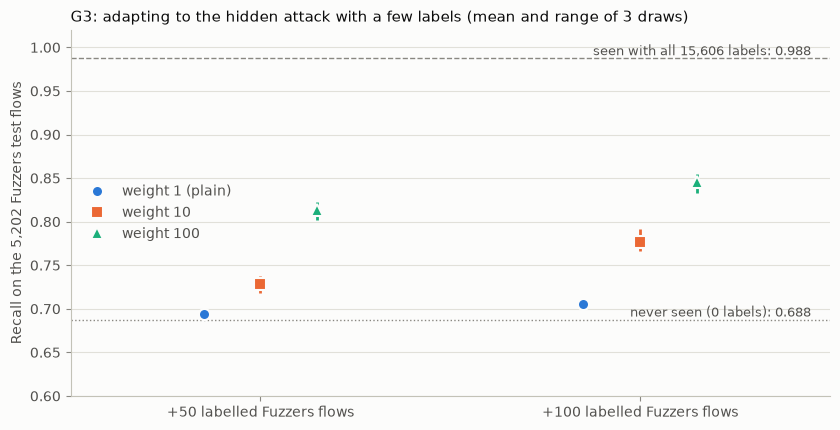

In [7]:
# STEP G3
# Figure: Fuzzers recall on the test set, from "never seen" to "seen with all labels". Dots are the
# mean of the 3 draws, the bars span the lowest and highest draw.
import matplotlib.pyplot as plt

SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
WEIGHT_STYLE = {1: ("#2a78d6", "o", "weight 1 (plain)"), 10: ("#eb6834", "s", "weight 10"),
                100: ("#1baf7a", "^", "weight 100")}
both = pd.concat([adapt_runs.assign(weight=1), weighted_runs])

fig, ax = plt.subplots(figsize=(8.5, 4.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
seen, hidden = hidden_report(boost)["fuzzers_recall"], hidden_report(boost_hidden)["fuzzers_recall"]
ax.axhline(seen, color=MUTED, linestyle="--", linewidth=1)
ax.text(2.45, seen, f"seen with all 15,606 labels: {seen:.3f}", va="bottom", ha="right", color=INK_2, fontsize=9)
ax.axhline(hidden, color=MUTED, linestyle=":", linewidth=1)
ax.text(2.45, hidden, f"never seen (0 labels): {hidden:.3f}", va="bottom", ha="right", color=INK_2, fontsize=9)
for offset, weight in zip([-0.15, 0.0, 0.15], [1, 10, 100]):
    colour, marker, label = WEIGHT_STYLE[weight]
    for x, n in zip([1, 2], [50, 100]):
        r = both[(both["weight"] == weight) & (both["labels_added"] == n)]["fuzzers_recall"]
        ax.vlines(x + offset, r.min(), r.max(), color=colour, linewidth=2)
        ax.plot(x + offset, r.mean(), marker=marker, color=colour, markersize=8, markeredgecolor=SURFACE,
                markeredgewidth=1.5, linestyle="none", label=label if n == 50 else None)
ax.set_xticks([1, 2], ["+50 labelled Fuzzers flows", "+100 labelled Fuzzers flows"])
ax.set_xlim(0.5, 2.5)
ax.set_ylim(0.6, 1.02)
ax.set_ylabel("Recall on the 5,202 Fuzzers test flows", color=INK_2)
ax.set_title("G3: adapting to the hidden attack with a few labels (mean and range of 3 draws)",
             loc="left", fontsize=11, color=INK)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.tick_params(colors=MUTED, labelcolor=INK_2)
ax.legend(loc="center left", frameon=False, labelcolor=INK_2)
fig.tight_layout()
fig.savefig(FIGURES / "G3_adapt.png", dpi=150, facecolor=SURFACE)
plt.show()

<!-- STEP G3 -->
### What adapting achieved

| Test set, mean of 3 draws (lowest to highest) | Recall on Fuzzers | Overall recall | FAR |
|---|---:|---:|---:|
| Never seen (0 labels, G2) | 0.688 | 0.888 | 0.019 |
| +50 labels | 0.694 (0.690 to 0.700) | 0.889 | 0.019 |
| +100 labels | 0.706 (0.703 to 0.712) | 0.893 | 0.019 |
| +50 labels, weight 10 | 0.729 (0.718 to 0.738) | 0.901 | 0.019 |
| +100 labels, weight 10 | 0.776 (0.766 to 0.792) | 0.917 | 0.020 |
| +50 labels, weight 100 | 0.814 (0.802 to 0.822) | 0.929 | 0.021 |
| +100 labels, weight 100 | **0.845** (0.833 to 0.854) | **0.940** | 0.022 |
| Seen with all 15,606 Fuzzers labels (B2) | 0.988 | 0.992 | 0.028 |

**Added as ordinary training flows, 50 or 100 labels barely help**: recall on Fuzzers rises from 0.688
to 0.694 and 0.706. Among 167,000 training flows, 100 new ones hardly change what the model learns.

**Given more weight, the same labels help clearly.** With each new flow counted 100 times, 100 labels
raise recall on Fuzzers to 0.845 (about 820 more fuzzing flows caught than without labels) and overall
recall to 0.940, while the false alarm rate rises only slightly (0.019 to 0.022, still below the
original model's 0.028). More labels and more weight both help, and the three draws give similar results,
so which flows the analyst labels matters little.

**But a few labels do not close the gap.** Even the best variant still misses 15% of the Fuzzers flows,
against 1% for the model trained with all of them. And the weights were not tuned (that would need
labels the analyst does not have), so 100 is a sensible guess, not an optimum. The optional extra X4 would
show how many labels are needed to come close to 0.988.

<!-- STEP G4 -->
## Part G: what we would do

**Were a few labels enough? No, but they were a good start.** Added as ordinary training flows, 50 or
100 labelled Fuzzers flows barely helped (recall on Fuzzers 0.688 to 0.706). Weighted 100 times, the same
100 labels raised it to 0.845, still well short of the 0.988 reached with all 15,606 labels, so we would
use a few weighted labels as a quick first fix and keep labelling until recall stops improving. **How would
we notice a new attack when nobody tells us?** Not from the alert count: when Fuzzers were unknown, the
false alarm rate *fell* (0.028 to 0.019) and the model raised fewer alerts, which looks like good news.
The useful signal is the model's own uncertainty, which needs no labels: the share of Fuzzers flows with
an attack probability between 0.1 and 0.9 jumped from 43% to 82%. In a real system we would therefore
watch the share of uncertain predictions and compare today's feature distributions with the training
data, have analysts label a small random sample of flows every week (including flows the model calls
benign), send uncertain flows (or BRB flows whose utility range spans the threshold, F4) to an analyst,
and retrain on a regular schedule.